In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# ile probek, jakie kolumny
df_cancer = pd.read_csv('..\\Data\\BreastCancerWisconsin_Diagnostics.csv')
print(df_cancer.shape)

df_cancer.head(1)

(569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,NaN


In [12]:
df_heart = pd.read_csv('..\\Data\\Heart_CardiacFeatures.csv')
print(df_heart.shape)

df_heart.head(1)

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1


In [13]:
# ile jest klas M, B
count_M = df_cancer['diagnosis'].value_counts()['M']
# malignant
print("Ilosc M: ", count_M)
count_B = df_cancer['diagnosis'].value_counts()['B']
# benign
print("Ilosc B: ", count_B)

Ilosc M:  212
Ilosc B:  357


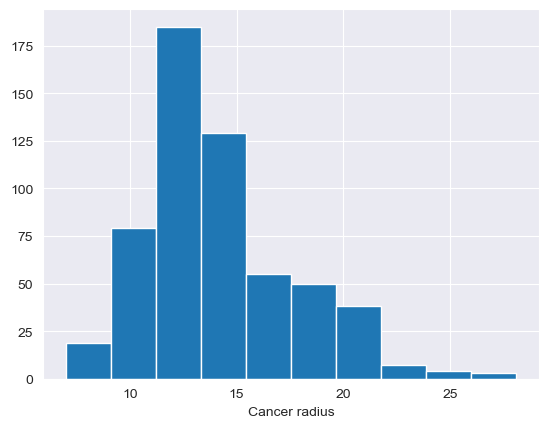

In [14]:
# histogram 1 cechy
plt.xlabel("Cancer radius")
plt.hist(df_cancer['radius_mean'])
plt.show()

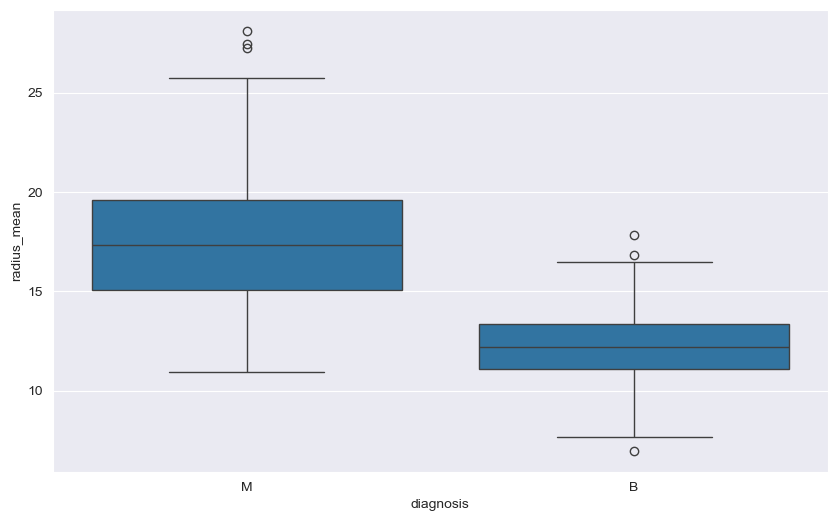

In [15]:
# boxplot cecha vs diganoza
plt.figure(figsize=(10,6))
sns.boxplot(x='diagnosis', y='radius_mean', data=df_cancer)
plt.show()

In [16]:
# numeric_cols = df_cancer.select_dtypes(include=["int64", "float64"]).columns.drop('id')
# # print(numeric_cols)
#
# for col in numeric_cols:
#     plt.figure()
#     sns.boxplot(x='diagnosis', y=col, data=df_cancer)
#     plt.title(f"Boxplot: {col}")
#     plt.show()

Napisz kod w Pythonie z użyciem scikit‑learn, który:

tworzy X i y z ramki df dla klasyfikacji 'diagnosis' M/B,

robi train_test_split z stratify,

liczy accuracy baseline (zawsze przewiduj najczęstszą klasę).

(uzyto Copilot)

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Zakładam, że df jest już wczytany
# y = kolumna 'diagnosis' (M/B), mapowanie M=1, B=0
y = df_cancer['diagnosis'].map({'M': 1, 'B': 0})

# X = wszystkie kolumny poza 'diagnosis' i ewentualnie 'id'
X = df_cancer.drop(columns=['diagnosis', 'id', 'Unnamed: 32'], errors='ignore')

# Train-test split z zachowaniem proporcji klas
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Obliczenie baseline accuracy:
# przewidujemy zawsze najczęstszą klasę w zbiorze treningowym
most_common_class = y_train.mode()[0]

y_pred_baseline = [most_common_class] * len(y_test)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print("Najczęstsza klasa:", most_common_class)
print("Baseline accuracy:", baseline_accuracy)


Najczęstsza klasa: 0
Baseline accuracy: 0.631578947368421


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Do AUC używamy prawdopodobieństw (predict_proba), co jest dokładniejsze
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
lr_pred = lr.predict(X_test_scaled)

print('Logistic accuracy:', accuracy_score(y_test, lr_pred))
print('Logistic AUC:', roc_auc_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic accuracy: 0.9649122807017544
Logistic AUC: 0.9573412698412699
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



która cecha jest najważniejsza??

np. czy rozmiar guza jest skorelowany?

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

print('RF accuracy:', accuracy_score(y_test, rf_pred))
print('RF AUC:', roc_auc_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

importances.head(10)

RF accuracy: 0.9736842105263158
RF AUC: 0.9642857142857143
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



,feature,importance
23,area_worst,0.151412
27,concave points_worst,0.126497
20,radius_worst,0.093475
22,perimeter_worst,0.083642
7,concave points_mean,0.081082
2,perimeter_mean,0.077126
0,radius_mean,0.061990
6,concavity_mean,0.050818
3,area_mean,0.045916
26,concavity_worst,0.030022


dla chętnych zadanie domowe

to samo z drugim dataset